# Credit Card Fraud Detection using Machine Learning

## Objective
Build a machine learning system that predicts whether a transaction is fraudulent or legitimate.

## Dataset
- fraudtrain.csv
- fraudtest.csv

## Workflow
1. Data Understanding
2. Exploratory Data Analysis
3. Data Preprocessing
4. Handling Imbalanced Data
5. Model Training
6. Model Evaluation
7. Model Explainability
8. Model Saving
9. Deployment Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from xgboost import XGBClassifier
import joblib
from imblearn.over_sampling import SMOTE

In [2]:
train_df=pd.read_csv("fraudTrain.csv")
test_df=pd.read_csv("fraudTest.csv")
print("Train Shape",train_df.shape)
print("Test Shape",test_df.shape)
train_df.head()

Train Shape (1296675, 23)
Test Shape (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
train_df.columns


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [4]:
# Remove useless Columns
drop_cols=["Unnamed: 0","first","last","street","trans_num"]
train_df.drop(columns=drop_cols,inplace=True)
test_df.drop(columns=drop_cols,inplace=True)

In [5]:
# Convert Time feature
train_df["trans_date_trans_time"] = pd.to_datetime(train_df["trans_date_trans_time"])
test_df["trans_date_trans_time"] = pd.to_datetime(test_df["trans_date_trans_time"])

In [6]:
train_df["hour"] = train_df["trans_date_trans_time"].dt.hour
train_df["day"] = train_df["trans_date_trans_time"].dt.day
train_df["month"] = train_df["trans_date_trans_time"].dt.month

test_df["hour"] = test_df["trans_date_trans_time"].dt.hour
test_df["day"] = test_df["trans_date_trans_time"].dt.day
test_df["month"] = test_df["trans_date_trans_time"].dt.month

In [7]:
train_df.drop(columns=["trans_date_trans_time"], inplace=True)
test_df.drop(columns=["trans_date_trans_time"], inplace=True)

In [8]:
# Create Age feature
train_df["dob"]=pd.to_datetime(train_df["dob"])
test_df["dob"] = pd.to_datetime(test_df["dob"])
train_df['age']=2026-train_df['dob'].dt.year
test_df['age']=2026-test_df['dob'].dt.year

In [9]:
train_df.drop(columns=["dob"], inplace=True)
test_df.drop(columns=["dob"], inplace=True)

In [10]:
# Encoded Categorical Features
from sklearn.preprocessing import OrdinalEncoder

cat_cols = train_df.select_dtypes(include="object").columns

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
test_df[cat_cols] = encoder.transform(test_df[cat_cols])

In [11]:
# Seperate features and Target
X = train_df.drop("is_fraud", axis=1)
y = train_df["is_fraud"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)# using stratify bcz fraud dataset are very much imbalanced

In [13]:
!pip install imbalanced-learn

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [15]:
# Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_val = scaler.transform(X_val)

In [16]:
# model training 
# 1. linear regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_res, y_train_res)

LogisticRegression()

In [25]:
# 2. RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20, random_state=42,n_jobs=-1)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=20, n_jobs=-1, random_state=42)

In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    

In [26]:
evaluate(lr, X_val, y_val)
evaluate(rf, X_val, y_val)
evaluate(xgb, X_val, y_val)

Accuracy: 0.9501802687643396
Precision: 0.08340021889821234
Recall: 0.7614923384410394
F1 Score: 0.15033539392345127
ROC AUC: 0.855299822432477
Accuracy: 0.9981876723157306
Precision: 0.8663823738450604
Recall: 0.8121252498334444
F1 Score: 0.8383768913342503
ROC AUC: 0.9837459860153992
Accuracy: 0.9967416661846646
Precision: 0.6515711645101664
Recall: 0.9393737508327782
F1 Score: 0.7694406548431105
ROC AUC: 0.9989237933002841


In [27]:
# improved performance using gridsearchcv
from sklearn.model_selection import GridSearchCV
params = {
    "max_depth":[4,6,8],
    "learning_rate":[0.01,0.1],
    "n_estimators":[100,200]
}

grid = GridSearchCV(xgb, params, cv=3, scoring="roc_auc")

grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_

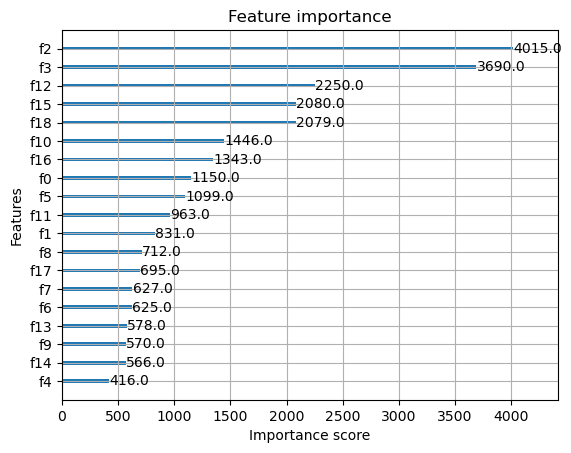

In [28]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(best_model)
plt.show()

In [29]:
evaluate(best_model, X_val, y_val)

Accuracy: 0.9978907590568185
Precision: 0.7564516129032258
Recall: 0.9373750832778148
F1 Score: 0.8372508182088664
ROC AUC: 0.9991261827372138


In [31]:
# save the model
import joblib
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(best_model, "fraud_model.pkl")

['fraud_model.pkl']

In [32]:
train_df.head()

,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,age
0,2703186189652095,514.0,8.0,4.97,0.0,526.0,27.0,28654,36.0788,-81.1781,3495,370.0,1325376018,36.011293,-82.048315,0,0,1,1,38
1,630423337322,241.0,4.0,107.23,0.0,612.0,47.0,99160,48.8878,-118.2105,149,428.0,1325376044,49.159047,-118.186462,0,0,1,1,48
2,38859492057661,390.0,0.0,220.11,1.0,468.0,13.0,83252,42.1808,-112.2620,4154,307.0,1325376051,43.150704,-112.154481,0,0,1,1,64
3,3534093764340240,360.0,2.0,45.00,1.0,84.0,26.0,59632,46.2306,-112.1138,1939,328.0,1325376076,47.034331,-112.561071,0,0,1,1,59
4,375534208663984,297.0,9.0,41.96,1.0,216.0,45.0,24433,38.4207,-79.4629,99,116.0,1325376186,38.674999,-78.632459,0,0,1,1,40
